# Santander

## Importar librerías

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import math
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


## Visionado de datos

In [21]:
# 1. leer normal (una sola cabecera)
df = pd.read_csv("../csv/santander_enriched.csv")
df.head()

,Unnamed: 0,Date,SAN_Adj_Close,SAN_Close,SAN_Volume,SAN_High,SAN_Low,SAN_Open,BBVA_Price,IBEX,SP500,EURUSD,OIL,eventos_negativos
0,0,2003-12-01,2.415460,7.746234,42034006,7.772199,7.538513,7.746234,9.895663,7372.299805,1070.119995,1.196501,29.950001,0
1,1,2003-12-02,2.404664,7.711614,187525101,7.763544,7.633719,7.711614,9.857233,7348.700195,1066.619995,1.208897,30.780001,0
2,2,2003-12-03,2.420857,7.763544,31459710,7.763544,7.651029,7.763544,9.924485,7384.299805,1064.729980,1.212298,31.100000,0
3,3,2003-12-04,2.410062,7.728924,37904447,7.746234,7.668339,7.728924,9.953307,7367.100098,1069.719971,1.208094,31.260000,0
4,4,2003-12-05,2.401965,7.702959,20656590,7.728924,7.651029,7.702959,9.857233,7348.100098,1061.500000,1.218695,30.730000,0


🔹 Correlación de las features con SAN_Close:

SAN_Close            1.000000
SAN_Low              0.999559
SAN_High             0.999557
SAN_Open             0.999088
BBVA_Price           0.900517
IBEX                 0.725916
EURUSD               0.693033
SAN_Adj_Close        0.463071
OIL                  0.182974
SAN_Volume           0.115335
eventos_negativos   -0.332917
SP500               -0.540704
Unnamed: 0          -0.753514
Name: SAN_Close, dtype: float64


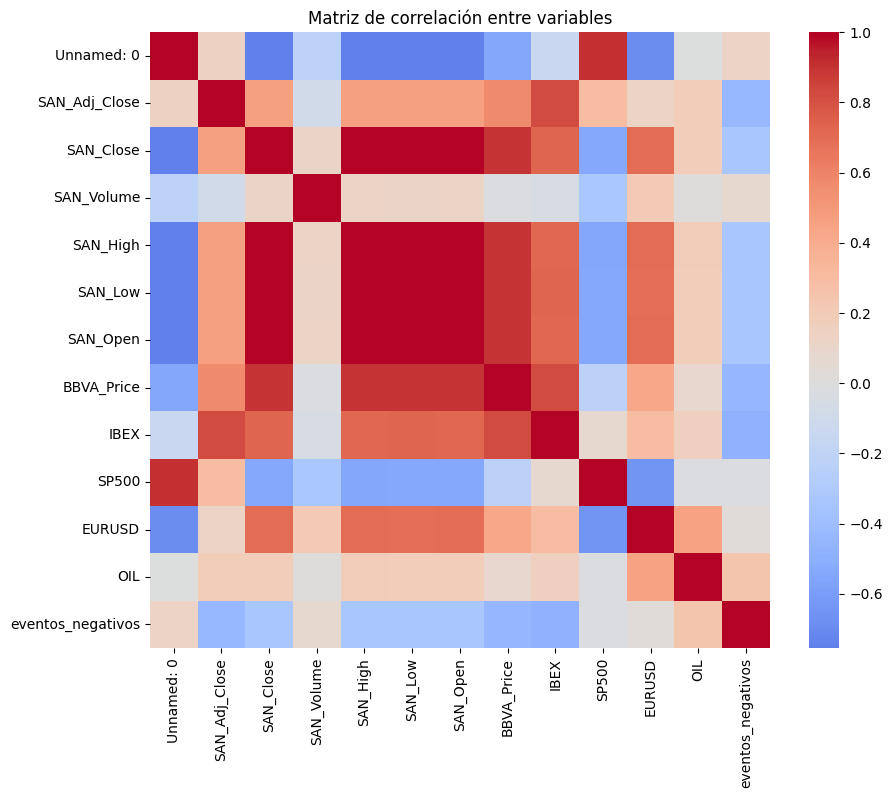

C:\Users\Usuario\AppData\Local\Temp\ipykernel_19244\2005514254.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cor_target.values, y=cor_target.index, palette="viridis")


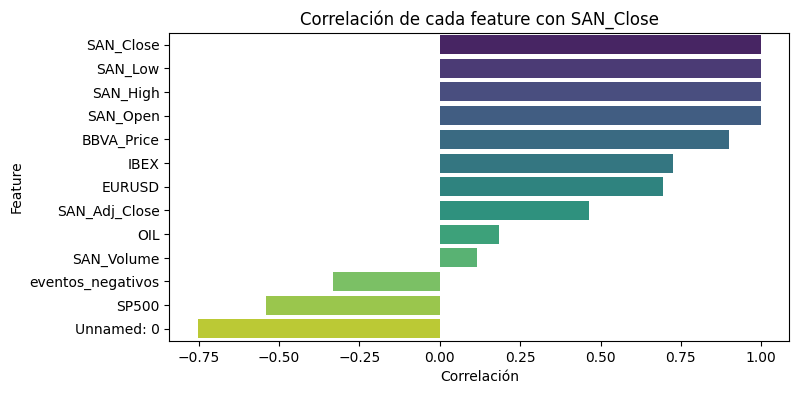

In [22]:
# --- 1️⃣ Calcular matriz de correlación ---
corr = df.corr(numeric_only=True)

# --- 2️⃣ Mostrar correlación de las features con la variable objetivo ---
target_col = "SAN_Close"
cor_target = corr[target_col].sort_values(ascending=False)

print("🔹 Correlación de las features con SAN_Close:\n")
print(cor_target)

# --- 3️⃣ (Opcional) Visualización de la matriz completa ---
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación entre variables")
plt.show()

# --- 4️⃣ (Opcional) Visualizar solo correlaciones con SAN_Close ---
plt.figure(figsize=(8, 4))
sns.barplot(x=cor_target.values, y=cor_target.index, palette="viridis")
plt.title("Correlación de cada feature con SAN_Close")
plt.xlabel("Correlación")
plt.ylabel("Feature")
plt.show()

In [23]:
df[df["SAN_Volume"] == 0][["Date"]]

,Date
510,2006-01-06


In [24]:
# Opción 1: Reemplazar por NaN y hacer interpolación
df["SAN_Volume"] = df["SAN_Volume"].replace(0, np.nan)
df["SAN_Volume"] = df["SAN_Volume"].interpolate()

In [25]:
df.head(10)

,Unnamed: 0,Date,SAN_Adj_Close,SAN_Close,SAN_Volume,SAN_High,SAN_Low,SAN_Open,BBVA_Price,IBEX,SP500,EURUSD,OIL,eventos_negativos
0,0,2003-12-01,2.415460,7.746234,42034006.0,7.772199,7.538513,7.746234,9.895663,7372.299805,1070.119995,1.196501,29.950001,0
1,1,2003-12-02,2.404664,7.711614,187525101.0,7.763544,7.633719,7.711614,9.857233,7348.700195,1066.619995,1.208897,30.780001,0
2,2,2003-12-03,2.420857,7.763544,31459710.0,7.763544,7.651029,7.763544,9.924485,7384.299805,1064.729980,1.212298,31.100000,0
3,3,2003-12-04,2.410062,7.728924,37904447.0,7.746234,7.668339,7.728924,9.953307,7367.100098,1069.719971,1.208094,31.260000,0
4,4,2003-12-05,2.401965,7.702959,20656590.0,7.728924,7.651029,7.702959,9.857233,7348.100098,1061.500000,1.218695,30.730000,0
5,5,2003-12-09,2.393868,7.676994,45362589.0,7.746234,7.651029,7.676994,9.857233,7391.000000,1060.180054,1.224995,31.760000,0
6,6,2003-12-10,2.374977,7.616409,36768915.0,7.668339,7.538513,7.616409,9.799588,7358.799805,1059.050049,1.219096,31.879999,0
7,7,2003-12-11,2.404664,7.711614,35375690.0,7.711614,7.555823,7.711614,9.905270,7432.200195,1071.209961,1.222404,31.850000,0
8,8,2003-12-12,2.404664,7.711614,30422674.0,7.763544,7.651029,7.711614,9.876448,7434.399902,1074.140015,1.227898,33.040001,0
9,9,2003-12-15,2.412760,7.737579,35197966.0,7.824129,7.728924,7.737579,9.914878,7471.799805,1068.040039,1.231997,33.180000,0


## Preparación de datos

In [18]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def preparar_datos_multivariados(df, target_col="SAN_Close", window_size=30):
    # 1. columnas que SÍ quieres usar como features
    feature_cols = ["BBVA_Price", "IBEX", "SP500", "EURUSD", "SAN_High", "SAN_Low", "SAN_Open", "eventos_negativos"]

    # 2. separo features y target
    features = df[feature_cols].copy()
    target = df[[target_col]].copy()

    # 3. escaladores independientes
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(features)
    y_scaled = scaler_y.fit_transform(target)

    X, y = [], []
    for i in range(window_size, len(X_scaled)):
        # secuencia de window_size pasos de TODAS las features
        X.append(X_scaled[i - window_size:i, :])
        # el target del paso actual
        y.append(y_scaled[i, 0])

    X = np.array(X)
    y = np.array(y)

    return X, y, scaler_X, scaler_y


## PREPROCESAMIENTO

In [19]:
def preparar_datos_multivariados(df, target_col="SAN_Close", window_size=30):
    df = df.sort_values("Date").reset_index(drop=True)

    features = df.drop(columns=["Date", target_col])
    target = df[[target_col]]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(features)
    y_scaled = scaler_y.fit_transform(target)

    X, y = [], []
    for i in range(window_size, len(X_scaled)):
        X.append(X_scaled[i-window_size:i, :])  # todas las features
        y.append(y_scaled[i, 0])

    X = np.array(X)
    y = np.array(y)
    return X, y, scaler_X, scaler_y

X, y, scaler_X, scaler_y = preparar_datos_multivariados(df, target_col="SAN_Close", window_size=30)
print(X.shape, y.shape)



(5382, 30, 12) (5382,)


## Train y test temporal

In [20]:
# 80% train, 20% test (temporal, sin shuffle)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (4305, 30, 12) (4305,)
Test : (1077, 30, 12) (1077,)


## Modelos

In [21]:
def build_rnn(window_size, n_features):
    model = Sequential([
        SimpleRNN(64, input_shape=(window_size, n_features)),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_lstm(window_size, n_features):
    model = Sequential([
        LSTM(64, input_shape=(window_size, n_features)),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_gru(window_size, n_features):
    model = Sequential([
        GRU(64, input_shape=(window_size, n_features)),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

## Entrenamiento

In [ ]:
# ==============================
# CONFIGURACIÓN BASE
# ==============================
EPOCHS_DEFAULT = 1000   # para RNN y GRU
EPOCHS_LSTM = 1000     # para LSTM
BATCH = 32
window_size = 30

# Crear carpeta 'modelos' fuera de notebooks si no existe
modelos_dir = os.path.join("..", "modelos")
os.makedirs(modelos_dir, exist_ok=True)

# ==============================
# FUNCIÓN DE ENTRENAMIENTO
# ==============================
def entrenar_modelo(nombre, build_fn, X_train, y_train, X_test, y_test, window_size):
    """
    Entrena un modelo (RNN, LSTM o GRU) con EarlyStopping y ModelCheckpoint.
    """
    print(f"\n🧠 Entrenando modelo {nombre}...\n")
    n_features = X_train.shape[2]   # <- número real de columnas de entrada
    model = build_fn(window_size, n_features)

    # Ruta completa donde guardar el modelo
    model_path = os.path.join(modelos_dir, f"mejor_{nombre.lower()}_santander.h5")

    # Configurar callbacks
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=100 if nombre != "LSTM" else 250,  # más paciencia para LSTM
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )

    # Número de épocas dinámico
    epochs = EPOCHS_LSTM if nombre == "LSTM" else EPOCHS_DEFAULT

    # Entrenamiento
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=BATCH,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    print(f"✅ Modelo {nombre} finalizado ({len(history.history['loss'])} epochs entrenadas)")
    return model, history

# ==============================
# ENTRENAR LOS TRES MODELOS
# ==============================

rnn_model,  hist_rnn  = entrenar_modelo("RNN",  build_rnn,  X_train, y_train, X_test, y_test, window_size)
lstm_model, hist_lstm = entrenar_modelo("LSTM", build_lstm, X_train, y_train, X_test, y_test, window_size)
gru_model,  hist_gru  = entrenar_modelo("GRU",  build_gru,  X_train, y_train, X_test, y_test, window_size)




🧠 Entrenando modelo RNN...

Epoch 1/1000


c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


131/135 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0835
Epoch 1: val_loss improved from None to 0.00143, saving model to ..\modelos\mejor_rnn_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0450 - val_loss: 0.0014
Epoch 2/1000
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0103
Epoch 2: val_loss did not improve from 0.00143
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0090 - val_loss: 0.0015
Epoch 3/1000
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0061
Epoch 3: val_loss improved from 0.00143 to 0.00099, saving model to ..\modelos\mejor_rnn_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0054 - val_loss: 9.8806e-04
Epoch 4/1000
129/135 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039
Epoch 4: val_loss improved from 0.00099 to 0.00085, saving model to ..\modelos\mejor_rnn_santander.h5


...

135/135 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0018 - val_loss: 6.3289e-04
Epoch 5/1000
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0017
Epoch 5: val_loss did not improve from 0.00063
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 6/1000
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0016
Epoch 6: val_loss improved from 0.00063 to 0.00063, saving model to ..\modelos\mejor_lstm_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0015 - val_loss: 6.2768e-04
Epoch 7/1000
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0016
Epoch 7: val_loss did not improve from 0.00063
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 8/1000
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0016
Epoch 8: val_loss improved from 0.00063 to 0.00060, saving model to ..\modelos\mejor_lstm_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0015 - val_loss: 5.9573e-04
Epoch 9/1000
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0013
Epoch 9: val_loss did not improve from 0.00060
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0014 - val_loss: 9.5399e-04
Epoch 10/1000
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0013
Epoch 10: val_loss did not improve from 0.00060
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 11/1000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0013
Epoch 11: val_loss did not improve from 0.00060
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 12/1000
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0013
Epoch 12: val_loss did not improve from 0.00060
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 13/1000
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0012
Epoch 13: val_loss improved from 0.00060 to 0.00051, saving model t

135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0012 - val_loss: 5.1296e-04
Epoch 14/1000
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0011
Epoch 14: val_loss did not improve from 0.00051
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 15/1000
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0011
Epoch 15: val_loss improved from 0.00051 to 0.00028, saving model to ..\modelos\mejor_lstm_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0012 - val_loss: 2.7890e-04
Epoch 16/1000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0010
Epoch 16: val_loss did not improve from 0.00028
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 9.9712e-04 - val_loss: 5.3851e-04
Epoch 17/1000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011
Epoch 17: val_loss did not improve from 0.00028
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0010 - val_loss: 5.7879e-04
Epoch 18/1000
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9.5390e-04
Epoch 18: val_loss did not improve from 0.00028
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 9.4644e-04 - val_loss: 4.4106e-04
Epoch 19/1000
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8.8676e-04
Epoch 19: val_loss did not improve from 0.00028
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 8.8984e-04 - val_loss: 7.2746e-04
Epoch 20/1000
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9.4812e-04
Epoch 20: val_loss did not im

# todas con la misma forma de entrada
input_shape = (window_size, 1)

def build_rnn():
    model = Sequential([
        SimpleRNN(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_lstm():
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_gru():
    model = Sequential([
        GRU(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

## Predicciones

In [ ]:
# predicciones (todavía en escala 0-1 porque el modelo se entrenó así)
y_pred_rnn  = rnn_model.predict(X_test)
y_pred_lstm = lstm_model.predict(X_test)
y_pred_gru  = gru_model.predict(X_test)

# desescalar la y real
y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# desescalar las predicciones
pred_rnn_real  = scaler_y.inverse_transform(y_pred_rnn)
pred_lstm_real = scaler_y.inverse_transform(y_pred_lstm)
pred_gru_real  = scaler_y.inverse_transform(y_pred_gru)



34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


## Métricas

In [ ]:
def evaluar(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

mae_rnn, rmse_rnn   = evaluar(y_test_real, pred_rnn_real)
mae_lstm, rmse_lstm = evaluar(y_test_real, pred_lstm_real)
mae_gru, rmse_gru   = evaluar(y_test_real, pred_gru_real)

print("RNN  -> MAE:", mae_rnn,  "RMSE:", rmse_rnn)
print("LSTM -> MAE:", mae_lstm, "RMSE:", rmse_lstm)
print("GRU  -> MAE:", mae_gru,  "RMSE:", rmse_gru)


RNN  -> MAE: 0.016584840480412016 RMSE: 0.026316548349295952
LSTM -> MAE: 0.005764837704731979 RMSE: 0.007821373643166148
GRU  -> MAE: 0.008838803294185925 RMSE: 0.011170032305140696


# Graficar

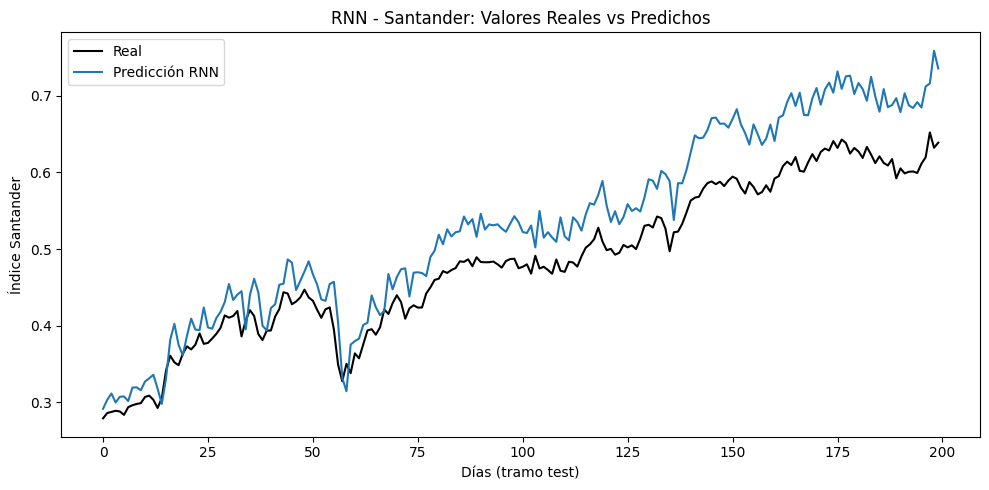

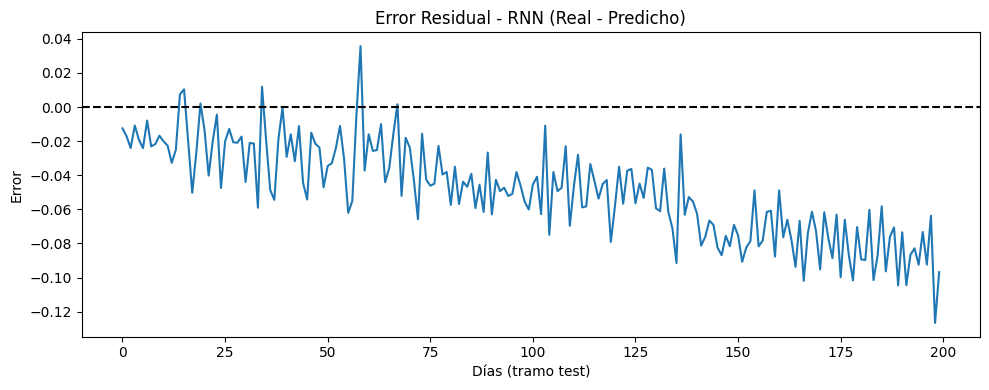

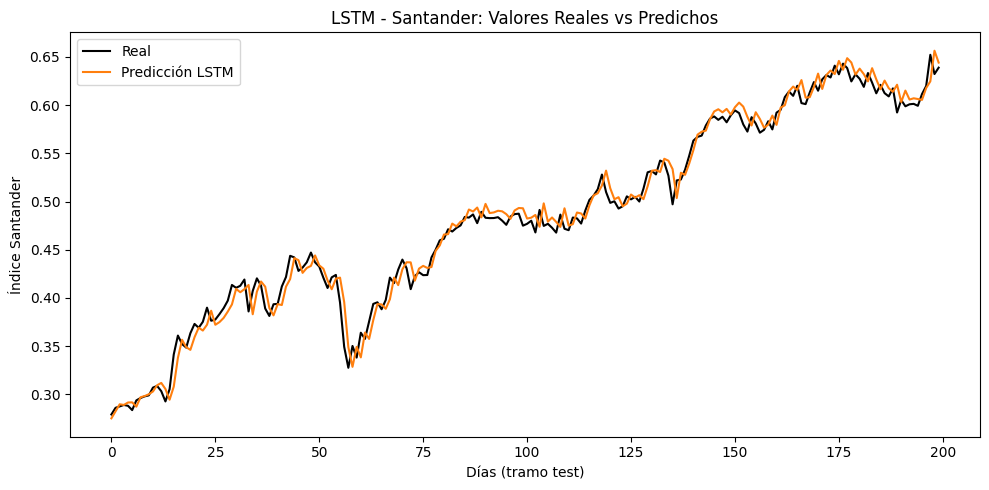

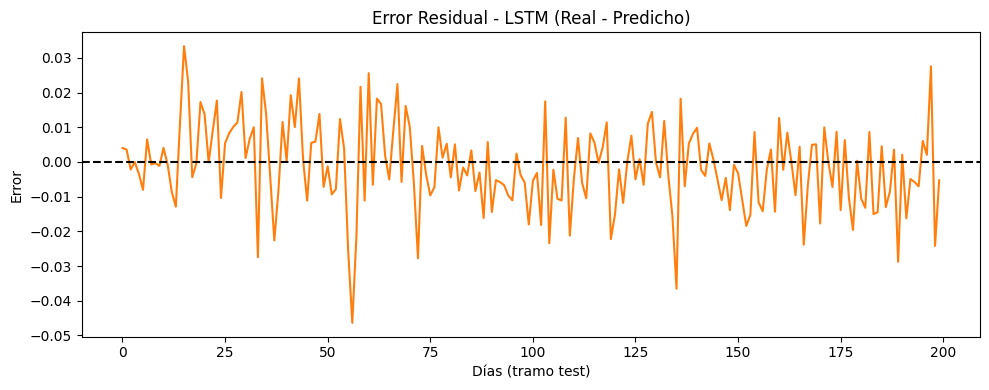

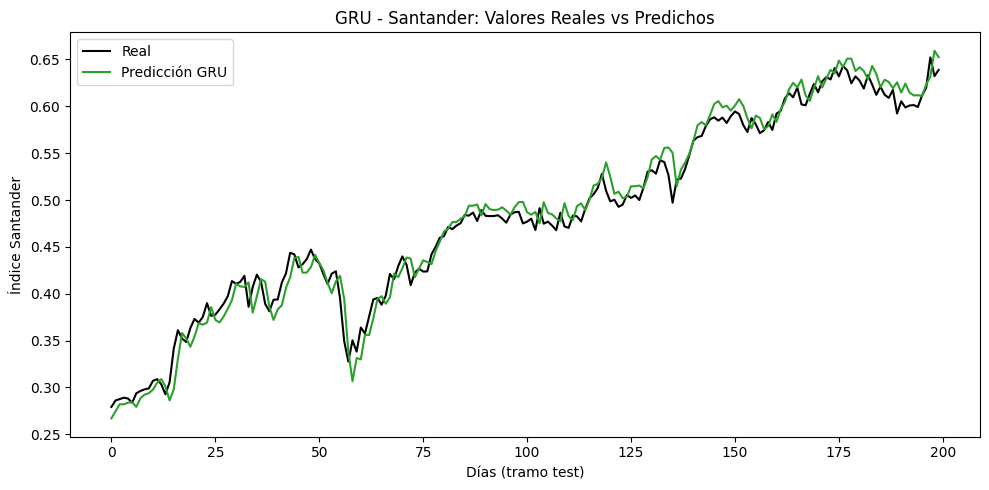

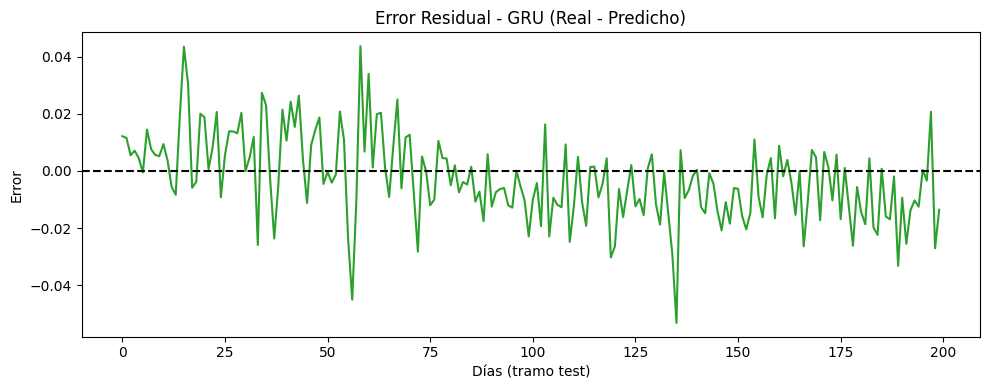

In [ ]:
# --- Tramo a mostrar (últimos 200 días del test, por ejemplo) ---
n_mostrar = 200
y_real_plot = y_test_real[-n_mostrar:]
pred_rnn_plot  = pred_rnn_real[-n_mostrar:]
pred_lstm_plot = pred_lstm_real[-n_mostrar:]
pred_gru_plot  = pred_gru_real[-n_mostrar:]

# ===============================
# 1️⃣ RNN
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_rnn_plot, label="Predicción RNN", color="tab:blue")
plt.title("RNN - Santander: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice Santander")
plt.legend()
plt.tight_layout()
plt.show()

# --- Error RNN ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_rnn_plot, color="tab:blue")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - RNN (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

# ===============================
# 2️⃣ LSTM
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_lstm_plot, label="Predicción LSTM", color="tab:orange")
plt.title("LSTM - Santander: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice Santander")
plt.legend()
plt.tight_layout()
plt.show()

# --- Error LSTM ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_lstm_plot, color="tab:orange")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - LSTM (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

# ===============================
# 3️⃣ GRU
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_gru_plot, label="Predicción GRU", color="tab:green")
plt.title("GRU - Santander: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice Santander")
plt.legend()
plt.tight_layout()
plt.show()

# --- Error GRU ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_gru_plot, color="tab:green")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - GRU (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()


## Predecir dias futuros

In [ ]:
def predecir_siguiente_multivariante(model, df_original, scaler_X, scaler_y, target_col="SAN_Close", window_size=30):
    """
    Predice el siguiente valor del target_col usando todas las features del dataset.
    """
    # Asegurarnos de tener las columnas ordenadas igual que durante el entrenamiento
    features = df_original.drop(columns=["Date", target_col])

    # 1️⃣ Tomamos los últimos window_size días de features
    ultimos = features.values[-window_size:]
    
    # 2️⃣ Escalamos las features con el scaler_X
    ultimos_scaled = scaler_X.transform(ultimos)

    # 3️⃣ Damos la forma adecuada al modelo (1 muestra, window_size pasos, n_features)
    X_input = ultimos_scaled.reshape((1, window_size, features.shape[1]))

    # 4️⃣ Predicción en escala 0–1
    pred_scaled = model.predict(X_input)

    # 5️⃣ Desescalar al valor real del precio
    pred_real = scaler_y.inverse_transform(pred_scaled)

    return pred_real[0, 0]



In [ ]:
pred_manana_lstm = predecir_siguiente_multivariante(
    lstm_model,
    df,             # tu dataframe limpio y completo (con Date, SAN_Close, IBEX, etc.)
    scaler_X,
    scaler_y,
    target_col="SAN_Close",
    window_size=window_size
)

print(f"Predicción Santander próximo día (LSTM): {pred_manana_lstm:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicción Santander próximo día (LSTM): 0.6528


c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
def predecir_n_dias_multivariante(model, df_original, scaler_X, scaler_y,
                                  target_col="SAN_Close", window_size=30, n_dias=5):
    # trabajamos con las mismas columnas que en el entrenamiento
    features = df_original.drop(columns=["Date", target_col])

    # tomamos los últimos window_size días de features
    ultimos_feat = features.values[-window_size:]  # (30, n_features)

    # lista donde guardaremos las predicciones desescaladas
    preds_reales = []

    # copia de trabajo de la ventana (en escala 0-1)
    ventana_scaled = scaler_X.transform(ultimos_feat)  # (30, n_features)

    for _ in range(n_dias):
        # (1, pasos, n_features)
        X_input = ventana_scaled.reshape((1, window_size, features.shape[1]))
        pred_scaled = model.predict(X_input, verbose=0)          # (1, 1)
        pred_real = scaler_y.inverse_transform(pred_scaled)[0,0] # float real
        preds_reales.append(pred_real)

        # ahora necesitamos actualizar la ventana con la predicción
        # pero ojo: la ventana tiene todas las features, y solo conocemos el target
        # lo más simple: mantenemos las features pasadas y solo metemos el target nuevo en su sitio

        # reconstruimos la última fila de features para el futuro:
        # usamos la última fila real de features (la más reciente)
        ultima_fila_real = features.values[-1:].copy()  # (1, n_features)
        # sustituimos en esa fila la columna del target por la predicción escalada
        # primero escalamos el valor predicho de nuevo para colocarlo en la ventana
        pred_scaled_full = scaler_y.transform(pred_scaled)[0,0]

        # buscamos el índice de la columna target en features+target
        # pero como en features NO está el target, tenemos que construir la fila futura así:
        # -> usamos la última fila real de features (sin target), y solo actualizamos más adelante.
        # actualizamos la ventana: quitamos la primera fila y agregamos la nueva fila de features escalada
        nueva_fila_feat_scaled = scaler_X.transform(ultima_fila_real)  # (1, n_features)
        # la ventana pasa a ser: desde la fila 1 hasta el final + nueva fila
        ventana_scaled = np.vstack([ventana_scaled[1:], nueva_fila_feat_scaled])

    return preds_reales


In [ ]:
# asegurarnos de que la columna Date es datetime
df["Date"] = pd.to_datetime(df["Date"])

# 1) predecimos 5 días
preds_5 = predecir_n_dias_multivariante(
    lstm_model,
    df,
    scaler_X,
    scaler_y,
    target_col="SAN_Close",
    window_size=window_size,
    n_dias=5
)

# 2) generar 5 fechas futuras (días laborables)
ultima_fecha = df["Date"].max()              # ahora sí es Timestamp
fechas_futuras = pd.date_range(
    start=ultima_fecha + pd.Timedelta(days=1),
    periods=5,
    freq="B"  # solo días hábiles
)

df_futuro = pd.DataFrame({
    "Date": fechas_futuras,
    "Predicted_SAN_Close": preds_5
})

# 3) histórico de 1 mes
historico_plot = df[["Date", "SAN_Close"]].tail(30).copy()


c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\

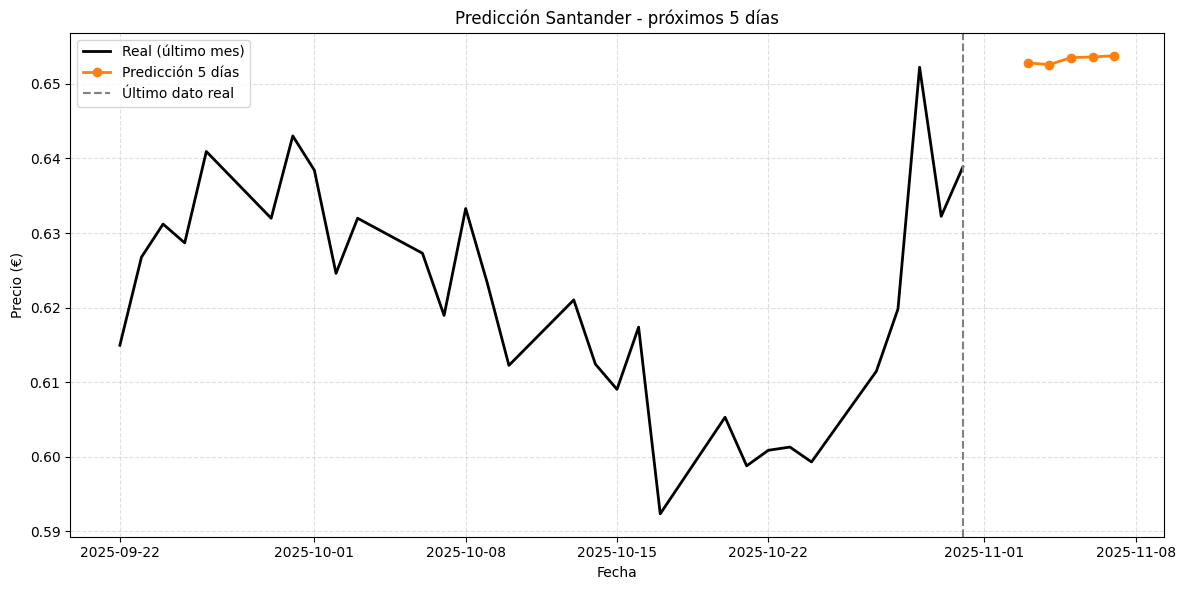

In [ ]:
plt.figure(figsize=(12,6))

# histórico
plt.plot(historico_plot["Date"], historico_plot["SAN_Close"],
         label="Real (último mes)", color="black", linewidth=2)

# futuro
plt.plot(df_futuro["Date"], df_futuro["Predicted_SAN_Close"],
         label="Predicción 5 días", color="tab:orange", marker="o", linewidth=2)

# línea de corte
plt.axvline(historico_plot["Date"].max(), color="gray", linestyle="--", label="Último dato real")

plt.title("Predicción Santander - próximos 5 días")
plt.xlabel("Fecha")
plt.ylabel("Precio (€)")

# 2 decimales en eje Y
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



In [ ]:
pred_manana_gru = predecir_siguiente_multivariante(
    gru_model,
    df,             # tu dataframe limpio y completo (con Date, SAN_Close, IBEX, etc.)
    scaler_X,
    scaler_y,
    target_col="SAN_Close",
    window_size=window_size
)

print(f"Predicción Santander próximo día (GRU): {pred_manana_gru:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicción Santander próximo día (GRU): 0.6555


c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
def predecir_n_dias_multivariante(model, df_original, scaler_X, scaler_y,
                                  target_col="SAN_Close", window_size=30, n_dias=5):
    # trabajamos con las mismas columnas que en el entrenamiento
    features = df_original.drop(columns=["Date", target_col])

    # tomamos los últimos window_size días de features
    ultimos_feat = features.values[-window_size:]  # (30, n_features)

    # lista donde guardaremos las predicciones desescaladas
    preds_reales = []

    # copia de trabajo de la ventana (en escala 0-1)
    ventana_scaled = scaler_X.transform(ultimos_feat)  # (30, n_features)

    for _ in range(n_dias):
        # (1, pasos, n_features)
        X_input = ventana_scaled.reshape((1, window_size, features.shape[1]))
        pred_scaled = model.predict(X_input, verbose=0)          # (1, 1)
        pred_real = scaler_y.inverse_transform(pred_scaled)[0,0] # float real
        preds_reales.append(pred_real)

        # ahora necesitamos actualizar la ventana con la predicción
        # pero ojo: la ventana tiene todas las features, y solo conocemos el target
        # lo más simple: mantenemos las features pasadas y solo metemos el target nuevo en su sitio

        # reconstruimos la última fila de features para el futuro:
        # usamos la última fila real de features (la más reciente)
        ultima_fila_real = features.values[-1:].copy()  # (1, n_features)
        # sustituimos en esa fila la columna del target por la predicción escalada
        # primero escalamos el valor predicho de nuevo para colocarlo en la ventana
        pred_scaled_full = scaler_y.transform(pred_scaled)[0,0]

        # buscamos el índice de la columna target en features+target
        # pero como en features NO está el target, tenemos que construir la fila futura así:
        # -> usamos la última fila real de features (sin target), y solo actualizamos más adelante.
        # actualizamos la ventana: quitamos la primera fila y agregamos la nueva fila de features escalada
        nueva_fila_feat_scaled = scaler_X.transform(ultima_fila_real)  # (1, n_features)
        # la ventana pasa a ser: desde la fila 1 hasta el final + nueva fila
        ventana_scaled = np.vstack([ventana_scaled[1:], nueva_fila_feat_scaled])

    return preds_reales

In [ ]:
# asegurarnos de que la columna Date es datetime
df["Date"] = pd.to_datetime(df["Date"])

# 1) predecimos 5 días
preds_5 = predecir_n_dias_multivariante(
    gru_model,
    df,
    scaler_X,
    scaler_y,
    target_col="SAN_Close",
    window_size=window_size,
    n_dias=5
)

# 2) generar 5 fechas futuras (días laborables)
ultima_fecha = df["Date"].max()              # ahora sí es Timestamp
fechas_futuras = pd.date_range(
    start=ultima_fecha + pd.Timedelta(days=1),
    periods=5,
    freq="B"  # solo días hábiles
)

df_futuro = pd.DataFrame({
    "Date": fechas_futuras,
    "Predicted_SAN_Close": preds_5
})

# 3) histórico de 1 mes
historico_plot = df[["Date", "SAN_Close"]].tail(30).copy()

c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\

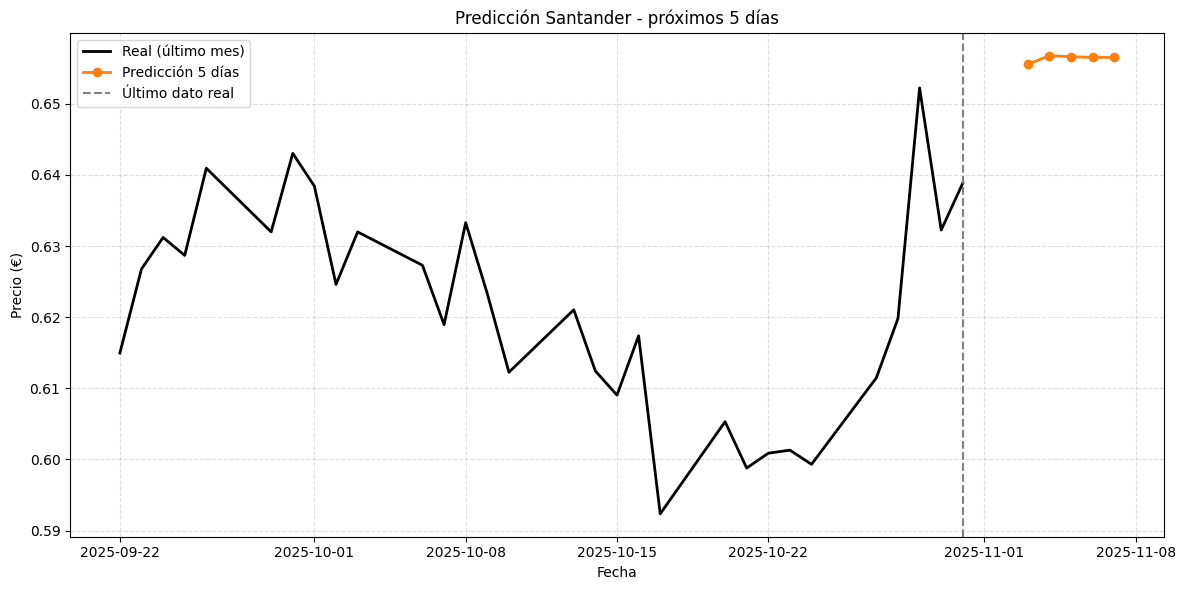

In [ ]:

plt.figure(figsize=(12,6))

# histórico
plt.plot(historico_plot["Date"], historico_plot["SAN_Close"],
         label="Real (último mes)", color="black", linewidth=2)

# futuro
plt.plot(df_futuro["Date"], df_futuro["Predicted_SAN_Close"],
         label="Predicción 5 días", color="tab:orange", marker="o", linewidth=2)

# línea de corte
plt.axvline(historico_plot["Date"].max(), color="gray", linestyle="--", label="Último dato real")

plt.title("Predicción Santander - próximos 5 días")
plt.xlabel("Fecha")
plt.ylabel("Precio (€)")

# 2 decimales en eje Y
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1) leer sin cabecera
df_raw = pd.read_csv("../csv/santander_data.csv", header=None)

# 2) la primera fila tiene los nombres buenos
column_names = df_raw.iloc[0].tolist()

# 3) nos quedamos con los datos reales (a partir de la fila 3 -> índice 3)
df_real = df_raw.iloc[3:].reset_index(drop=True)

# 4) poner nombres
df_real.columns = column_names

# 5) renombrar 'Price' -> 'Date' porque en realidad es la fecha
df_real = df_real.rename(columns={"Price": "Date"})

# 6) convertir Date a datetime
df_real["Date"] = pd.to_datetime(df_real["Date"])

# 7) convertir el resto a numérico
for col in df_real.columns:
    if col != "Date":
        df_real[col] = pd.to_numeric(df_real[col], errors="coerce")

# ordenar por fecha por si acaso
df_real = df_real.sort_values("Date").reset_index(drop=True)

print(df_real.head())


        Date  Adj Close     Close  Dividends      High       Low      Open  \
0 2000-01-03   2.625067  9.849401        0.0  9.987881  9.736886  9.953261   
1 2000-01-04   2.562785  9.615716        0.0  9.780161  9.529166  9.728231   
2 2000-01-05   2.500503  9.382031        0.0  9.555131  9.304136  9.433961   
3 2000-01-06   2.500503  9.382031        0.0  9.382031  9.382031  9.382031   
4 2000-01-07   2.611226  9.797471        0.0  9.823436  9.442616  9.451271   

   Stock Splits   Volume  
0           0.0  8797337  
1           0.0  8811013  
2           0.0  9333517  
3           0.0        0  
4           0.0  9603132  


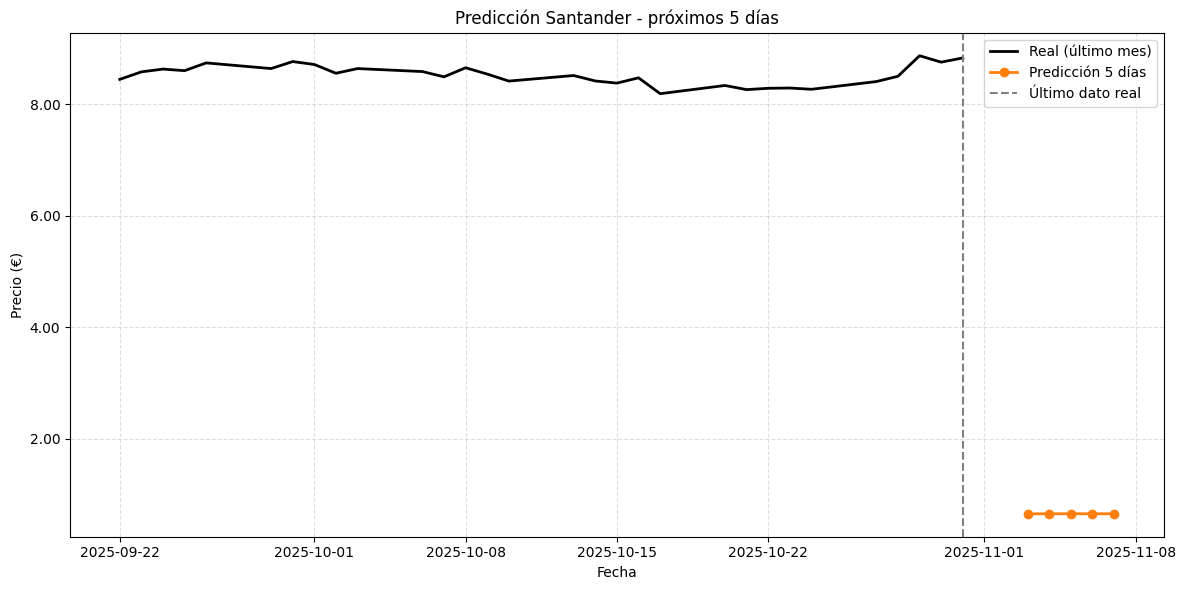

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# asegurarnos por si acaso
df_real["Date"] = pd.to_datetime(df_real["Date"])

# histórico: últimos 30 días REALES del CSV
historico_plot = df_real[["Date", "Adj Close"]].tail(30).copy()

# aquí van tus fechas futuras y predicciones (venía de antes)
# fechas_futuras = ...
# preds_5 = ...

df_futuro = pd.DataFrame({
    "Date": fechas_futuras,
    "Predicted": preds_5
})

plt.figure(figsize=(12,6))

# parte real
plt.plot(
    historico_plot["Date"],
    historico_plot["Adj Close"],
    label="Real (último mes)",
    color="black",
    linewidth=2
)

# parte futura
plt.plot(
    df_futuro["Date"],
    df_futuro["Predicted"],
    label="Predicción 5 días",
    color="tab:orange",
    marker="o",
    linewidth=2
)

# línea de corte
plt.axvline(historico_plot["Date"].max(), color="gray", linestyle="--", label="Último dato real")

plt.title("Predicción Santander - próximos 5 días")
plt.xlabel("Fecha")
plt.ylabel("Precio (€)")

# 2 decimales en el eje Y
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

